# Step 1 – Dataset Exploration

## Objective

The objective of this step is to explore and understand the agricultural dataset before performing data cleaning and seasonal analysis.

## Observations

* The dataset contains **4000 rows** and **28 columns**.
* It includes information about farms, crops, seasons, weather, soil conditions, irrigation, yield, revenue, profit, and water usage.
* There are **120 missing values** in the dataset, which will be handled during the data cleaning stage.
* The dataset contains three seasons: **Kharif, Rabi, and Zaid**.

## Conclusion

The dataset provides sufficient information to compare agricultural performance across different seasons and perform meaningful data analysis.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv("seasonal_agriculture_performance_dataset (2).csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:

df.shape

(4000, 28)

In [5]:

df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [6]:

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [7]:

df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [8]:

df.isnull().sum().sum()

np.int64(120)

In [9]:

df["Season"].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


# Step 2 – Data Cleaning

## Objective

The objective of this step is to clean the dataset by checking duplicate records, handling missing values, and preparing the data for seasonal agricultural analysis.


In [10]:

df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [12]:
df.isnull().sum().sum()

np.int64(120)

In [13]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
df.to_csv("cleaned_seasonal_agriculture_dataset.csv", index=False)

# Step 3 – Exploratory Data Analysis (EDA)

## Objective

The objective of this step is to analyze seasonal agricultural data using visualizations to identify patterns, trends, and differences in agricultural performance across Kharif, Rabi, and Zaid seasons.


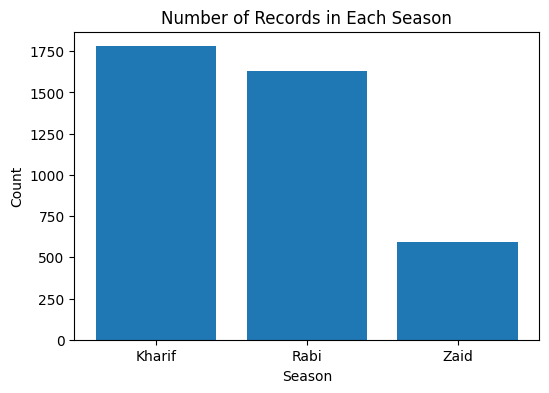

In [16]:

season_counts = df["Season"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(season_counts.index, season_counts.values)
plt.title("Number of Records in Each Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.show()

Observation: Kharif has the highest number of records, followed by Rabi and Zaid. This indicates that most agricultural activities in the dataset belong to the Kharif season.

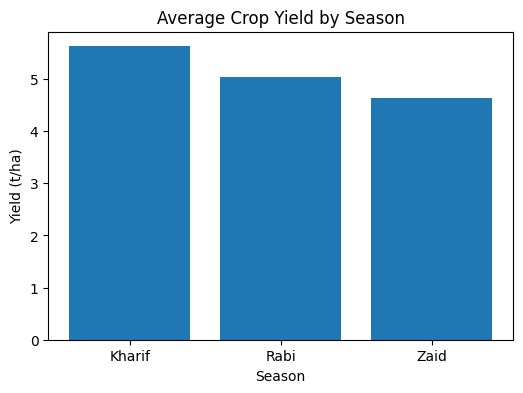

In [21]:

avg_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

plt.figure(figsize=(6,4))
plt.bar(avg_yield.index, avg_yield.values)
plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (t/ha)")
plt.show()

Observation: This graph compares the average crop yield across Kharif, Rabi, and Zaid seasons. It helps identify which season has better agricultural productivity.

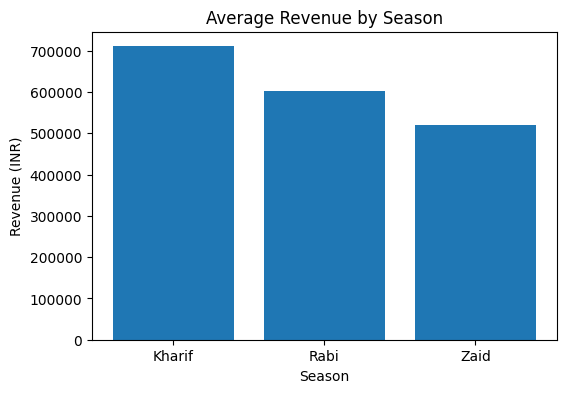

In [22]:
avg_revenue = df.groupby("Season")["Revenue_INR"].mean()

plt.figure(figsize=(6,4))
plt.bar(avg_revenue.index, avg_revenue.values)
plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue (INR)")
plt.show()

Observation: This graph compares the average revenue generated during Kharif, Rabi, and Zaid seasons. It helps identify which season performs better economically

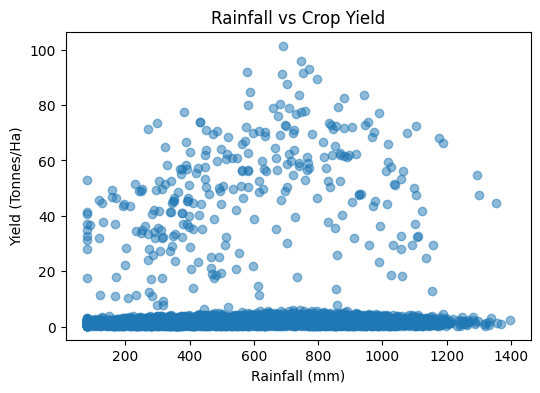

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(df["Rainfall_mm"], df["Yield_Tonnes_Ha"], alpha=0.5)
plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

Observation: The scatter plot helps visualize whether higher rainfall is associated with higher crop yield.

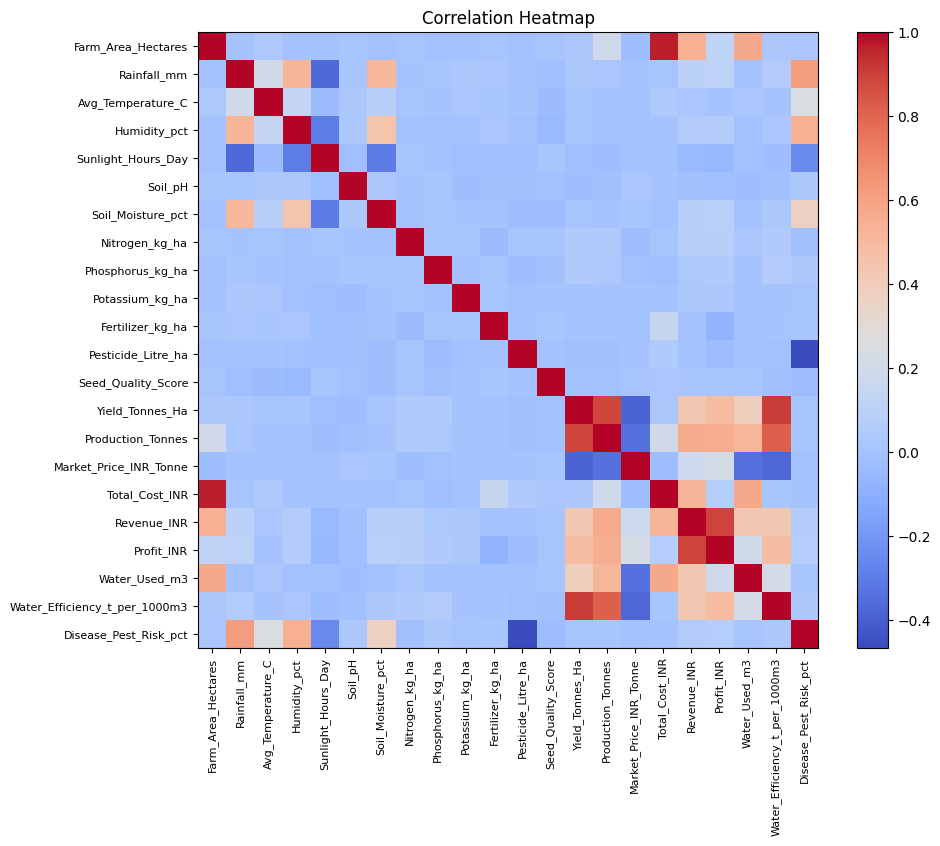

In [24]:
corr = df.select_dtypes(include=["float64","int64"]).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=8)

plt.title("Correlation Heatmap")
plt.show()

Observation: The heatmap shows positive and negative relationships among numerical variables. Darker colors indicate stronger relationships

## Conclusion

The exploratory data analysis identified seasonal differences in agricultural records, crop yield, revenue, and environmental factors. These visualizations provide the foundation for interpreting seasonal agricultural performance and developing data-driven insights.


# Step 4 – Seasonal Performance Analysis

## Objective

The objective of this step is to interpret the visualizations and identify seasonal patterns, differences, and relationships in agricultural performance.


## Insight 1 – Distribution of Records by Season

The dataset contains agricultural records from three seasons: Kharif, Rabi, and Zaid.

* Kharif contains the highest number of records.
* Rabi contains the second-highest number.
* Zaid contains the fewest records.

This indicates that Kharif farming activities are more frequently represented in the dataset.


## Insight 2 – Average Crop Yield by Season

The bar chart compares the average crop yield across different seasons.

* The graph shows that crop productivity varies across seasons.
* The season with the tallest bar has the highest average yield.
* Seasonal conditions influence agricultural productivity.


## Insight 3 – Revenue Comparison

The revenue graph compares average income generated across different seasons.

* Revenue changes between Kharif, Rabi, and Zaid.
* Economic performance is influenced by seasonal agricultural activities.
* Seasonal comparison helps identify stronger-performing periods.


## Insight 4 – Rainfall and Crop Yield

The scatter plot shows the relationship between rainfall and crop yield.

* Each point represents one farm.
* The graph helps identify whether rainfall affects agricultural productivity.
* Rainfall is one of the important environmental factors influencing farming outcomes.


## Insight 5 – Correlation Analysis

The heatmap compares relationships among numerical variables.

Key observations:

* Red colors indicate positive relationships.
* Blue colors indicate negative relationships.
* Darker colors represent stronger relationships.
* The heatmap helps identify which variables are closely related.


## Conclusion

Seasonal analysis shows that agricultural performance changes across different seasons. The visualizations highlight differences in crop yield, revenue, rainfall patterns, and relationships among numerical variables, providing useful insights for evidence-based agricultural planning.


In [25]:

df.describe().round(2)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,...,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,600.92,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,...,0.83,5.24,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,287.19,3.82,11.96,1.12,0.64,6.68,31.22,17.02,27.74,...,0.10,13.31,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,...,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,371.58,23.90,54.78,6.60,6.26,21.80,98.50,46.20,86.20,...,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.90,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,...,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,831.98,29.60,71.90,8.10,7.14,31.20,141.22,69.40,123.60,...,0.91,2.83,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,...,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


## Statistical Summary

The statistical summary provides important information such as count, mean, minimum, maximum, and standard deviation for numerical variables. It helps understand the overall distribution of agricultural data before drawing conclusions.


# Step 6 – Final Conclusions and Recommendations

## Objective

The objective of this step is to summarize the findings from the seasonal agricultural analysis and provide practical recommendations based on the observed patterns.


## Final Conclusions

The seasonal agricultural analysis identified noticeable differences in farming activities, crop yield, revenue, and environmental conditions across Kharif, Rabi, and Zaid seasons.

Major findings include:

* Kharif has the highest number of records in the dataset.
* Agricultural performance varies across different seasons.
* Revenue and crop yield differ between seasons.
* Rainfall shows a relationship with crop productivity.
* Correlation analysis helps identify important relationships among numerical variables.

These findings demonstrate that seasonal conditions influence agricultural performance and highlight the value of data-driven analysis for understanding farming patterns.


## Recommendations

Based on the analysis, the following recommendations can support better agricultural planning:

1. Monitor seasonal trends before making farming decisions.
2. Improve irrigation planning according to rainfall conditions.
3. Focus on resource management to improve crop productivity.
4. Use data analytics regularly to compare seasonal performance.
5. Study high-performing seasons further to identify best farming practices.


## Future Scope

The project can be extended by:

* Building a crop yield prediction model using machine learning.
* Developing an interactive dashboard using Power BI or Tableau.
* Integrating real-time weather data.
* Creating region-wise seasonal comparisons.
* Developing a farmer decision-support system.


In [26]:
df.to_csv("cleaned_seasonal_agriculture_dataset.csv", index=False)